# Trader Performance vs Bitcoin Sentiment (Colab edition)

Self-contained Colab notebook for the Primetrade.ai assignment. Just run all cells. The first cell installs dependencies and the second downloads the two source CSVs from Google Drive.

GitHub repo with the modular version: <fill in after push>


In [1]:
!pip -q install gdown pandas numpy matplotlib seaborn scipy

In [2]:
# === inlined src/ modules so the notebook is self-contained on Colab ===
from pathlib import Path
import numpy as np
import pandas as pd

RAW_DIR = Path("data/raw")
TRADES_FILE = RAW_DIR / "historical_trades.csv"
SENTIMENT_FILE = RAW_DIR / "fear_greed.csv"
TRADES_GDRIVE_ID = "1IAfLZwu6rJzyWKgBToqwSmmVYU6VbjVs"
SENTIMENT_GDRIVE_ID = "1PgQC0tO8XN-wqkNyghWc_-mnrYv_nhSf"

def download_raw():
    import gdown
    RAW_DIR.mkdir(parents=True, exist_ok=True)
    if not TRADES_FILE.exists():
        gdown.download(id=TRADES_GDRIVE_ID, output=str(TRADES_FILE), quiet=False)
    if not SENTIMENT_FILE.exists():
        gdown.download(id=SENTIMENT_GDRIVE_ID, output=str(SENTIMENT_FILE), quiet=False)

def load_trades():
    df = pd.read_csv(TRADES_FILE)
    df.columns = [c.strip() for c in df.columns]
    df["ts"] = pd.to_datetime(df["Timestamp IST"], format="%d-%m-%Y %H:%M", errors="coerce")
    bad = df["ts"].isna().sum()
    if bad:
        print(f"dropped {bad} rows with unparseable Timestamp IST")
        df = df[df["ts"].notna()].copy()
    df["date"] = df["ts"].dt.date.astype("datetime64[ns]")
    df = df.rename(columns={
        "Closed PnL": "closed_pnl", "Size USD": "size_usd", "Size Tokens": "size_tokens",
        "Execution Price": "exec_price", "Start Position": "start_position",
        "Account": "account", "Coin": "coin", "Side": "side", "Direction": "direction", "Fee": "fee",
    })
    return df

def load_sentiment():
    df = pd.read_csv(SENTIMENT_FILE)
    df.columns = [c.strip() for c in df.columns]
    df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d", errors="raise").dt.normalize()
    df = df.rename(columns={"value": "fg_value", "classification": "regime"})
    return df[["date", "fg_value", "regime"]]

REGIME_ORDER = ["Extreme Fear", "Fear", "Neutral", "Greed", "Extreme Greed"]
BINARY_MAP = {"Extreme Fear":"Fear","Fear":"Fear","Neutral":"Neutral","Greed":"Greed","Extreme Greed":"Greed"}

def attach_sentiment(trades, sentiment):
    out = trades.merge(sentiment, on="date", how="left")
    out["regime"] = pd.Categorical(out["regime"], categories=REGIME_ORDER, ordered=True)
    out["regime_binary"] = out["regime"].map(BINARY_MAP)
    return out

def add_trade_features(df):
    df = df.copy()
    df["is_win"] = df["closed_pnl"] > 0
    df["notional"] = df["size_usd"].abs()
    df["side_norm"] = df["side"].str.upper()
    mapped = df["side_norm"].map({"BUY": 1, "SELL": -1})
    if mapped.isna().any():
        print(f"warning: {mapped.isna().sum()} trades with unrecognised side")
    df["signed_size"] = df["size_usd"] * mapped.fillna(0)
    return df

def pnl_total(df): return float(df["closed_pnl"].sum())
def pnl_mean(df):  return float(df["closed_pnl"].mean()) if len(df) else 0.0
def pnl_median(df):return float(df["closed_pnl"].median()) if len(df) else 0.0
def win_rate(df):
    closes = df[df["closed_pnl"] != 0]
    if len(closes) == 0: return float("nan")
    return float((closes["closed_pnl"] > 0).mean())
def profit_factor(df):
    pos = df.loc[df["closed_pnl"] > 0, "closed_pnl"].sum()
    neg = df.loc[df["closed_pnl"] < 0, "closed_pnl"].sum()
    if neg == 0: return float("inf") if pos > 0 else float("nan")
    return float(pos / abs(neg))
def sharpe(df, periods_per_year=365):
    if len(df) == 0: return float("nan")
    daily = df.groupby("date")["closed_pnl"].sum()
    if len(daily) < 2 or daily.std(ddof=1) == 0: return float("nan")
    return float((daily.mean() / daily.std(ddof=1)) * np.sqrt(periods_per_year))
def max_drawdown(df):
    if len(df) == 0: return float("nan")
    daily = df.groupby("date")["closed_pnl"].sum().sort_index().cumsum()
    if len(daily) == 0: return float("nan")
    return float((daily - daily.cummax()).min())
def trading_frequency(df):
    if len(df) == 0: return float("nan")
    active = df["date"].nunique()
    return float(len(df) / active) if active else float("nan")
def roi(df):
    notional = df["notional"].sum() if "notional" in df.columns else df["size_usd"].abs().sum()
    if notional == 0: return float("nan")
    return float(df["closed_pnl"].sum() / notional)
def risk_proxy(df):
    if len(df) < 2: return float("nan")
    return float(df["closed_pnl"].std(ddof=1))
def all_metrics(df):
    return {
        "trades": int(len(df)),
        "pnl_total": pnl_total(df), "pnl_mean": pnl_mean(df), "pnl_median": pnl_median(df),
        "win_rate": win_rate(df), "profit_factor": profit_factor(df),
        "sharpe": sharpe(df), "max_drawdown": max_drawdown(df),
        "trading_frequency": trading_frequency(df), "roi": roi(df), "risk_std": risk_proxy(df),
    }
def metrics_by_group(df, group_col):
    rows = []
    for key, sub in df.groupby(group_col, observed=True):
        m = all_metrics(sub); m[group_col] = key; rows.append(m)
    out = pd.DataFrame(rows)
    cols = [group_col] + [c for c in out.columns if c != group_col]
    return out[cols]

print("helpers loaded")


helpers loaded


In [3]:
download_raw()
sent = load_sentiment()
trades = load_trades()
df = attach_sentiment(trades, sent)
df = add_trade_features(df)
print('joined shape:', df.shape)
print('trades without a regime label:', df['regime'].isna().sum())


joined shape: (211224, 25)
trades without a regime label: 6


## Regime-level metric table

In [4]:
regime_table = metrics_by_group(df.dropna(subset=['regime']), 'regime')
regime_table = regime_table.set_index('regime').reindex(REGIME_ORDER).reset_index()
regime_table.round(4)


,regime,trades,pnl_total,pnl_mean,pnl_median,win_rate,profit_factor,sharpe,max_drawdown,trading_frequency,roi,risk_std
0,Extreme Fear,21400,7.391102e+05,34.5379,0.0,0.7622,2.1615,9.9605,-86890.7563,1528.5714,0.0065,1136.0561
1,Fear,61837,3.357155e+06,54.2904,0.0,0.8729,6.6556,7.2953,-135685.6661,679.5275,0.0069,935.3554
2,Neutral,37686,1.292921e+06,34.3077,0.0,0.8239,4.3213,9.7032,-10116.8756,562.4776,0.0072,517.1222
3,Greed,50303,2.150129e+06,42.7436,0.0,0.7689,3.0309,3.4094,-419020.2257,260.6373,0.0075,1116.0284
4,Extreme Greed,39992,2.715171e+06,67.8929,0.0,0.8917,11.0228,6.2481,-137369.6087,350.8070,0.0218,766.8283


## Headline charts

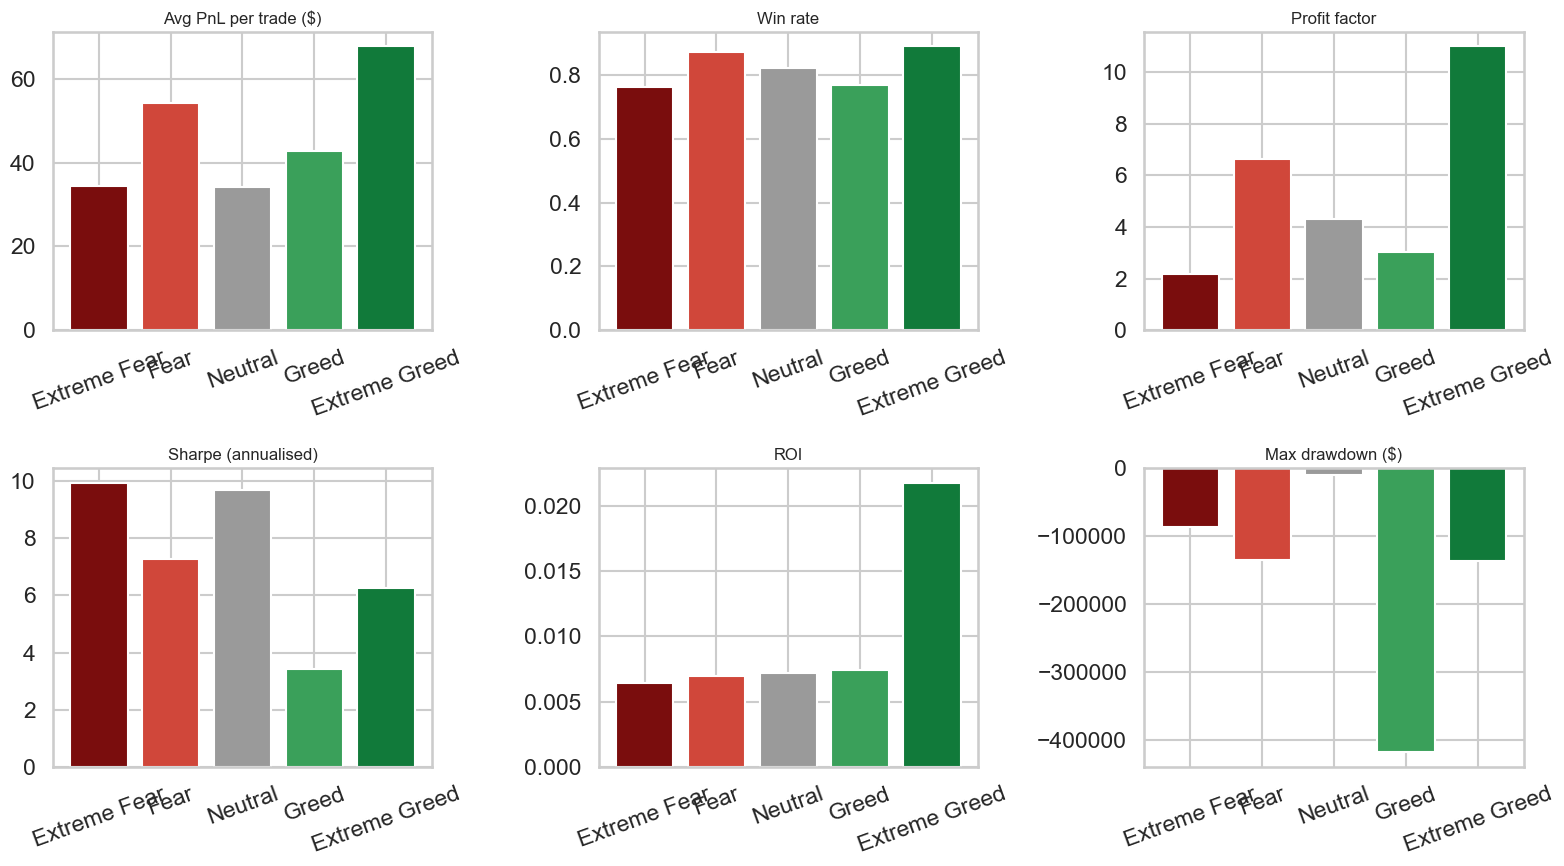

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', context='talk')

PALETTE = {'Extreme Fear':'#7a0d0d','Fear':'#d0473a','Neutral':'#9a9a9a','Greed':'#3aa05a','Extreme Greed':'#117a3a'}

metrics_to_plot = ['pnl_mean', 'win_rate', 'profit_factor', 'sharpe', 'roi', 'max_drawdown']
titles = {
    'pnl_mean':'Avg PnL per trade ($)','win_rate':'Win rate','profit_factor':'Profit factor',
    'sharpe':'Sharpe (annualised)','roi':'ROI','max_drawdown':'Max drawdown ($)',
}
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, m in zip(axes.flat, metrics_to_plot):
    vals = regime_table.set_index('regime')[m].reindex(REGIME_ORDER)
    ax.bar(vals.index, vals.values, color=[PALETTE[r] for r in vals.index])
    ax.set_title(titles[m], fontsize=12)
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()


## Statistical tests

In [6]:
from scipy import stats

binary = df.dropna(subset=['regime']).copy()
fear = binary.loc[binary['regime_binary'] == 'Fear', 'closed_pnl']
greed = binary.loc[binary['regime_binary'] == 'Greed', 'closed_pnl']
t_stat, t_p = stats.ttest_ind(fear, greed, equal_var=False)
u_stat, u_p = stats.mannwhitneyu(fear, greed, alternative='two-sided')
print(f'Welch t: t={t_stat:.4f}, p={t_p:.4g}')
print(f'Mann-Whitney U: U={u_stat:.0f}, p={u_p:.4g}')

daily_pnl = df.dropna(subset=['regime']).groupby('date').agg(
    pnl=('closed_pnl','sum'), trades=('closed_pnl','size'),
    wins=('is_win','sum'), fg_value=('fg_value','first'))
daily_pnl['win_rate'] = daily_pnl['wins'] / daily_pnl['trades']
r1, p1 = stats.spearmanr(daily_pnl['fg_value'], daily_pnl['pnl'])
r2, p2 = stats.spearmanr(daily_pnl['fg_value'], daily_pnl['win_rate'])
print(f'Spearman fg vs daily PnL: rho={r1:.4f}, p={p1:.4g}')
print(f'Spearman fg vs daily win rate: rho={r2:.4f}, p={p2:.4g}')

side_tbl = pd.crosstab(df['regime'], df['side'])
chi2, p_chi, dof, _ = stats.chi2_contingency(side_tbl)
print(f'chi2 side x regime: chi2={chi2:.2f}, p={p_chi:.4g}')


Welch t: t=-0.9875, p=0.3234
Mann-Whitney U: U=3725766115, p=0.000954
Spearman fg vs daily PnL: rho=0.0398, p=0.3842
Spearman fg vs daily win rate: rho=0.1905, p=2.716e-05
chi2 side x regime: chi2=327.24, p=1.439e-69


## Trader ranking and contrarian detection

In [7]:
MIN_TRADES = 200
per_trader = df.dropna(subset=['regime']).groupby('account').size()
active = per_trader[per_trader >= MIN_TRADES].index
trader_df = df[df['account'].isin(active)].dropna(subset=['regime'])

def rank_within_regime(slice_df, label):
    rows = []
    for acc, sub in slice_df.groupby('account'):
        m = all_metrics(sub); m['account'] = acc; rows.append(m)
    out = pd.DataFrame(rows)
    out = out[out['trades'] >= 20]
    out = out.sort_values('pnl_total', ascending=False).reset_index(drop=True)
    out['rank'] = np.arange(1, len(out) + 1)
    out.insert(0, 'regime', label)
    return out

overall = rank_within_regime(trader_df, 'overall')
print('Top 10 overall by total PnL:')
overall.head(10)[['rank','account','trades','pnl_total','win_rate','sharpe','profit_factor']]


Top 10 overall by total PnL:


,rank,account,trades,pnl_total,win_rate,sharpe,profit_factor
0,1,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,14733,2.143383e+06,0.791050,4.006875,3.609562e+01
1,2,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06,0.792725,8.469632,4.708739e+00
2,3,0xbaaaf6571ab7d571043ff1e313a9609a10637864,21192,9.401638e+05,0.991197,8.580967,2.720837e+04
3,4,0x513b8629fe877bb581bf244e326a047b249c4ff1,12236,8.404226e+05,0.895476,9.762431,5.902045e+00
4,5,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,40184,8.360806e+05,0.763070,4.757560,3.862477e+00
5,6,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,4356,6.777471e+05,0.948500,8.808588,5.280461e+01
6,7,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,1590,4.293556e+05,0.746269,5.382131,7.446678e+00
7,8,0x430f09841d65beb3f27765503d0f850b8bce7713,1237,4.165419e+05,1.000000,8.684930,inf
8,9,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,9893,3.790954e+05,0.926328,10.416422,8.604447e+00
9,10,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,1424,3.605395e+05,0.774194,4.527417,9.297094e+00


In [8]:
fear_rank = rank_within_regime(trader_df[trader_df['regime_binary'] == 'Fear'], 'Fear')
greed_rank = rank_within_regime(trader_df[trader_df['regime_binary'] == 'Greed'], 'Greed')

f = fear_rank[['account','trades','pnl_mean','win_rate','sharpe']].add_suffix('_fear').rename(columns={'account_fear':'account'})
g = greed_rank[['account','trades','pnl_mean','win_rate','sharpe']].add_suffix('_greed').rename(columns={'account_greed':'account'})
contra = f.merge(g, on='account', how='inner')
contra = contra[(contra['trades_fear'] >= 50) & (contra['trades_greed'] >= 50)]
contra['edge'] = contra['win_rate_fear'] - contra['win_rate_greed']

print('Fear specialists:')
print(contra.sort_values('edge', ascending=False).head(5)[['account','win_rate_fear','win_rate_greed','edge','sharpe_fear','sharpe_greed']].round(3).to_string(index=False))
print('\nGreed specialists:')
print(contra.sort_values('edge', ascending=True).head(5)[['account','win_rate_fear','win_rate_greed','edge','sharpe_fear','sharpe_greed']].round(3).to_string(index=False))


Fear specialists:
                                   account  win_rate_fear  win_rate_greed  edge  sharpe_fear  sharpe_greed
0x271b280974205ca63b716753467d5a371de622ab          0.955           0.439 0.516       31.724        -7.567
0x083384f897ee0f19899168e3b1bec365f52a9012          0.894           0.388 0.506       18.470         2.807
0x8477e447846c758f5a675856001ea72298fd9cb5          0.822           0.554 0.268       11.502         1.424
0x8170715b3b381dffb7062c0298972d4727a0a63b          0.849           0.686 0.163       10.609        -4.040
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23          0.875           0.729 0.146        4.685         4.185

Greed specialists:
                                   account  win_rate_fear  win_rate_greed   edge  sharpe_fear  sharpe_greed
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891          0.534           0.931 -0.397       -4.713         4.185
0x8381e6d82f1affd39a336e143e081ef7620a3b7f          0.659           0.954 -0.295       -6.132         4.

## Headline takeaways

- Extreme Greed is the strongest regime: 89.2 percent win rate, profit factor 11.0, ROI 2.18 percent.
- Plain Greed is the weakest: lowest Sharpe (3.41) and worst drawdown ($-419k).
- Long share drops from 51.1 percent in Extreme Fear to 44.9 percent in Extreme Greed; the cohort runs a contrarian short bias as the market overheats.
- 28 traders qualify for the contrarian set; some show 50+ point win-rate gaps between regimes.

Full writeup, modular code, tests, and saved figures live in the GitHub repo.